# LeetCode #315: Count of Smaller Numbers After Self

https://leetcode.com/problems/count-of-smaller-numbers-after-self/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (nested loops)** | $O(n^2)$ | $O(1)$ |
| **Merge Sort (modified)** | $O(n \log n)$ | $O(n)$ |
| **Binary Indexed Tree (BIT) + Coordinate Compression** | $O(n \log n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force (nested loops)
For each element at index $i$, scan all elements to its right and count those smaller than `nums[i]`. Simple but $O(n^2)$ — too slow for $n = 10^5$.

### Merge Sort (modified)
A modified merge sort that counts inversions during the merge step. When a right-half element is placed before a left-half element, it contributes to counts of all remaining left-half elements. Same asymptotic complexity as BIT but harder to implement correctly.

### Optimal: Binary Indexed Tree (BIT) + Coordinate Compression ★
Compress values to indices 1…n, then scan the array **right to left**. For each element: (1) query the BIT for the prefix sum up to `rank(nums[i]) - 1` — this gives the count of smaller elements already seen to the right; (2) update the BIT at `rank(nums[i])` by +1. Coordinate compression maps arbitrary values to a dense 1-indexed rank array so the BIT size stays $O(n)$.

**Why this is better than Merge Sort:** BIT is simpler to implement correctly — query and update are each a clean loop. Merge Sort requires carefully tracking indices during the merge step, which is error-prone.

**Constraints:**
* 1 <= nums.length <= 10^5
* -10^4 <= nums[i] <= 10^4

## Solutions

### C#

In [ ]:
public class Solution {
    private int[] bit;
    private int n;

    public IList<int> CountSmaller(int[] nums) {
        // Coordinate compression: map values to 1-indexed ranks
        int[] sorted = (int[])nums.Clone();
        Array.Sort(sorted);
        sorted = sorted.Distinct().ToArray();
        int rank(int v) => Array.BinarySearch(sorted, v) + 1;

        n = sorted.Length;
        bit = new int[n + 1];
        int len = nums.Length;
        int[] result = new int[len];

        // Scan right to left: query then update
        for (int i = len - 1; i >= 0; i--) {
            int r = rank(nums[i]);
            // Count elements already inserted with rank < r
            result[i] = Query(r - 1);
            Update(r, 1);
        }
        return result;
    }

    private void Update(int i, int delta) {
        for (; i <= n; i += i & -i) bit[i] += delta;
    }

    private int Query(int i) {
        int sum = 0;
        for (; i > 0; i -= i & -i) sum += bit[i];
        return sum;
    }
}

### Python

In [ ]:
from bisect import bisect_left, insort

class Solution:
    def countSmaller(self, nums: list[int]) -> list[int]:
        # Coordinate compression: map values to 1-indexed ranks
        sorted_unique = sorted(set(nums))
        rank = {v: i + 1 for i, v in enumerate(sorted_unique)}
        n = len(sorted_unique)
        bit = [0] * (n + 1)

        def update(i: int) -> None:
            while i <= n:
                bit[i] += 1
                i += i & -i

        def query(i: int) -> int:
            s = 0
            while i > 0:
                s += bit[i]
                i -= i & -i
            return s

        result = []
        # Scan right to left: query then update
        for v in reversed(nums):
            r = rank[v]
            # Count elements already inserted with rank < r
            result.append(query(r - 1))
            update(r)
        return result[::-1]

### Go

In [ ]:
func countSmaller(nums []int) []int {
    // Coordinate compression: map values to 1-indexed ranks
    sorted := make([]int, len(nums))
    copy(sorted, nums)
    sort.Ints(sorted)
    // deduplicate
    unique := sorted[:0]
    for i, v := range sorted {
        if i == 0 || v != sorted[i-1] {
            unique = append(unique, v)
        }
    }
    rankOf := func(v int) int {
        lo, hi := 0, len(unique)-1
        for lo <= hi {
            mid := (lo + hi) / 2
            if unique[mid] == v { return mid + 1 }
            if unique[mid] < v { lo = mid + 1 } else { hi = mid - 1 }
        }
        return -1
    }
    n := len(unique)
    bit := make([]int, n+1)
    update := func(i int) {
        for ; i <= n; i += i & -i { bit[i]++ }
    }
    query := func(i int) int {
        s := 0
        for ; i > 0; i -= i & -i { s += bit[i] }
        return s
    }

    result := make([]int, len(nums))
    // Scan right to left: query then update
    for i := len(nums) - 1; i >= 0; i-- {
        r := rankOf(nums[i])
        // Count elements already inserted with rank < r
        result[i] = query(r - 1)
        update(r)
    }
    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn count_smaller(nums: Vec<i32>) -> Vec<i32> {
        // Coordinate compression: map values to 1-indexed ranks
        let mut sorted: Vec<i32> = nums.clone();
        sorted.sort();
        sorted.dedup();
        let rank = |v: i32| -> usize {
            sorted.partition_point(|&x| x < v) + 1
        };
        let n = sorted.len();
        let mut bit = vec![0i32; n + 1];

        let update = |bit: &mut Vec<i32>, mut i: usize| {
            while i <= n { bit[i] += 1; i += i & i.wrapping_neg(); }
        };
        let query = |bit: &Vec<i32>, mut i: usize| -> i32 {
            let mut s = 0;
            while i > 0 { s += bit[i]; i -= i & i.wrapping_neg(); }
            s
        };

        let mut result = vec![0i32; nums.len()];
        // Scan right to left: query then update
        for i in (0..nums.len()).rev() {
            let r = rank(nums[i]);
            // Count elements already inserted with rank < r
            result[i] = query(&bit, r - 1);
            update(&mut bit, r);
        }
        result
    }
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [5, 2, 6, 1]
Compressed ranks: 1→1, 2→2, 5→3, 6→4. Scan right to left:
- i=3, v=1, rank=1: query(0)=0 → result[3]=0; update(1)
- i=2, v=6, rank=4: query(3)=1 (one element with rank≤3 inserted) → result[2]=1; update(4)
- i=1, v=2, rank=2: query(1)=1 (element "1" inserted) → result[1]=1; update(2)
- i=0, v=5, rank=3: query(2)=2 ("1" and "2" inserted) → result[0]=2; update(3)
Result: [2, 1, 1, 0].

**2. Slightly Complex**
**Input:** nums = [2, 0, 1]
Compressed ranks: 0→1, 1→2, 2→3. Scan right to left:
- i=2, v=1, rank=2: query(1)=0 → result[2]=0; update(2)
- i=1, v=0, rank=1: query(0)=0 → result[1]=0; update(1)
- i=0, v=2, rank=3: query(2)=2 ("0" at rank 1 and "1" at rank 2 both inserted) → result[0]=2; update(3)
Result: [2, 0, 0].

**3. Edge Case: Time Factor**
**Input:** nums = [10^4, 10^4−1, …, 1] (reverse sorted, n=10^5)
Every element has a smaller element to its right. For element at index $i$ (value $n-i$), query returns exactly $i$ — the BIT returns a prefix sum over $i$ positions. Each BIT query and update runs in $O(\log n)$. Total: $n \cdot O(\log n) = O(n \log n) \approx 10^5 \cdot 17 = 1.7 \times 10^6$ operations. Maximum time case: result is [n-1, n-2, …, 1, 0].

**4. Edge Case: Space Factor**
**Input:** nums = [−10^4, −10^4+1, …, 10^4] (all distinct values, n=2×10^4+1 values)
Coordinate compression maps all distinct values to ranks 1…n. BIT array size = $n+1 = 20001$ integers. Plus the rank map ($O(n)$) and the result array ($O(n)$). Total extra space: $O(n)$ with a small constant. This is the maximum distinct value count given $-10^4 \leq \text{nums}[i] \leq 10^4$.

**5. Almost-Impossible but Plausible**
**Input:** nums = [0] (single element)
- Compress: unique=[0], rank(0)=1, n=1, BIT=[0,0]
- i=0, v=0, rank=1: query(0)=0 → result[0]=0; update(1)
Result: [0]. Single element has nothing to its right. BIT query for prefix(0) = 0 by definition (empty prefix). No edge case needed in the BIT itself — the $i=0$ base case returns 0 naturally.

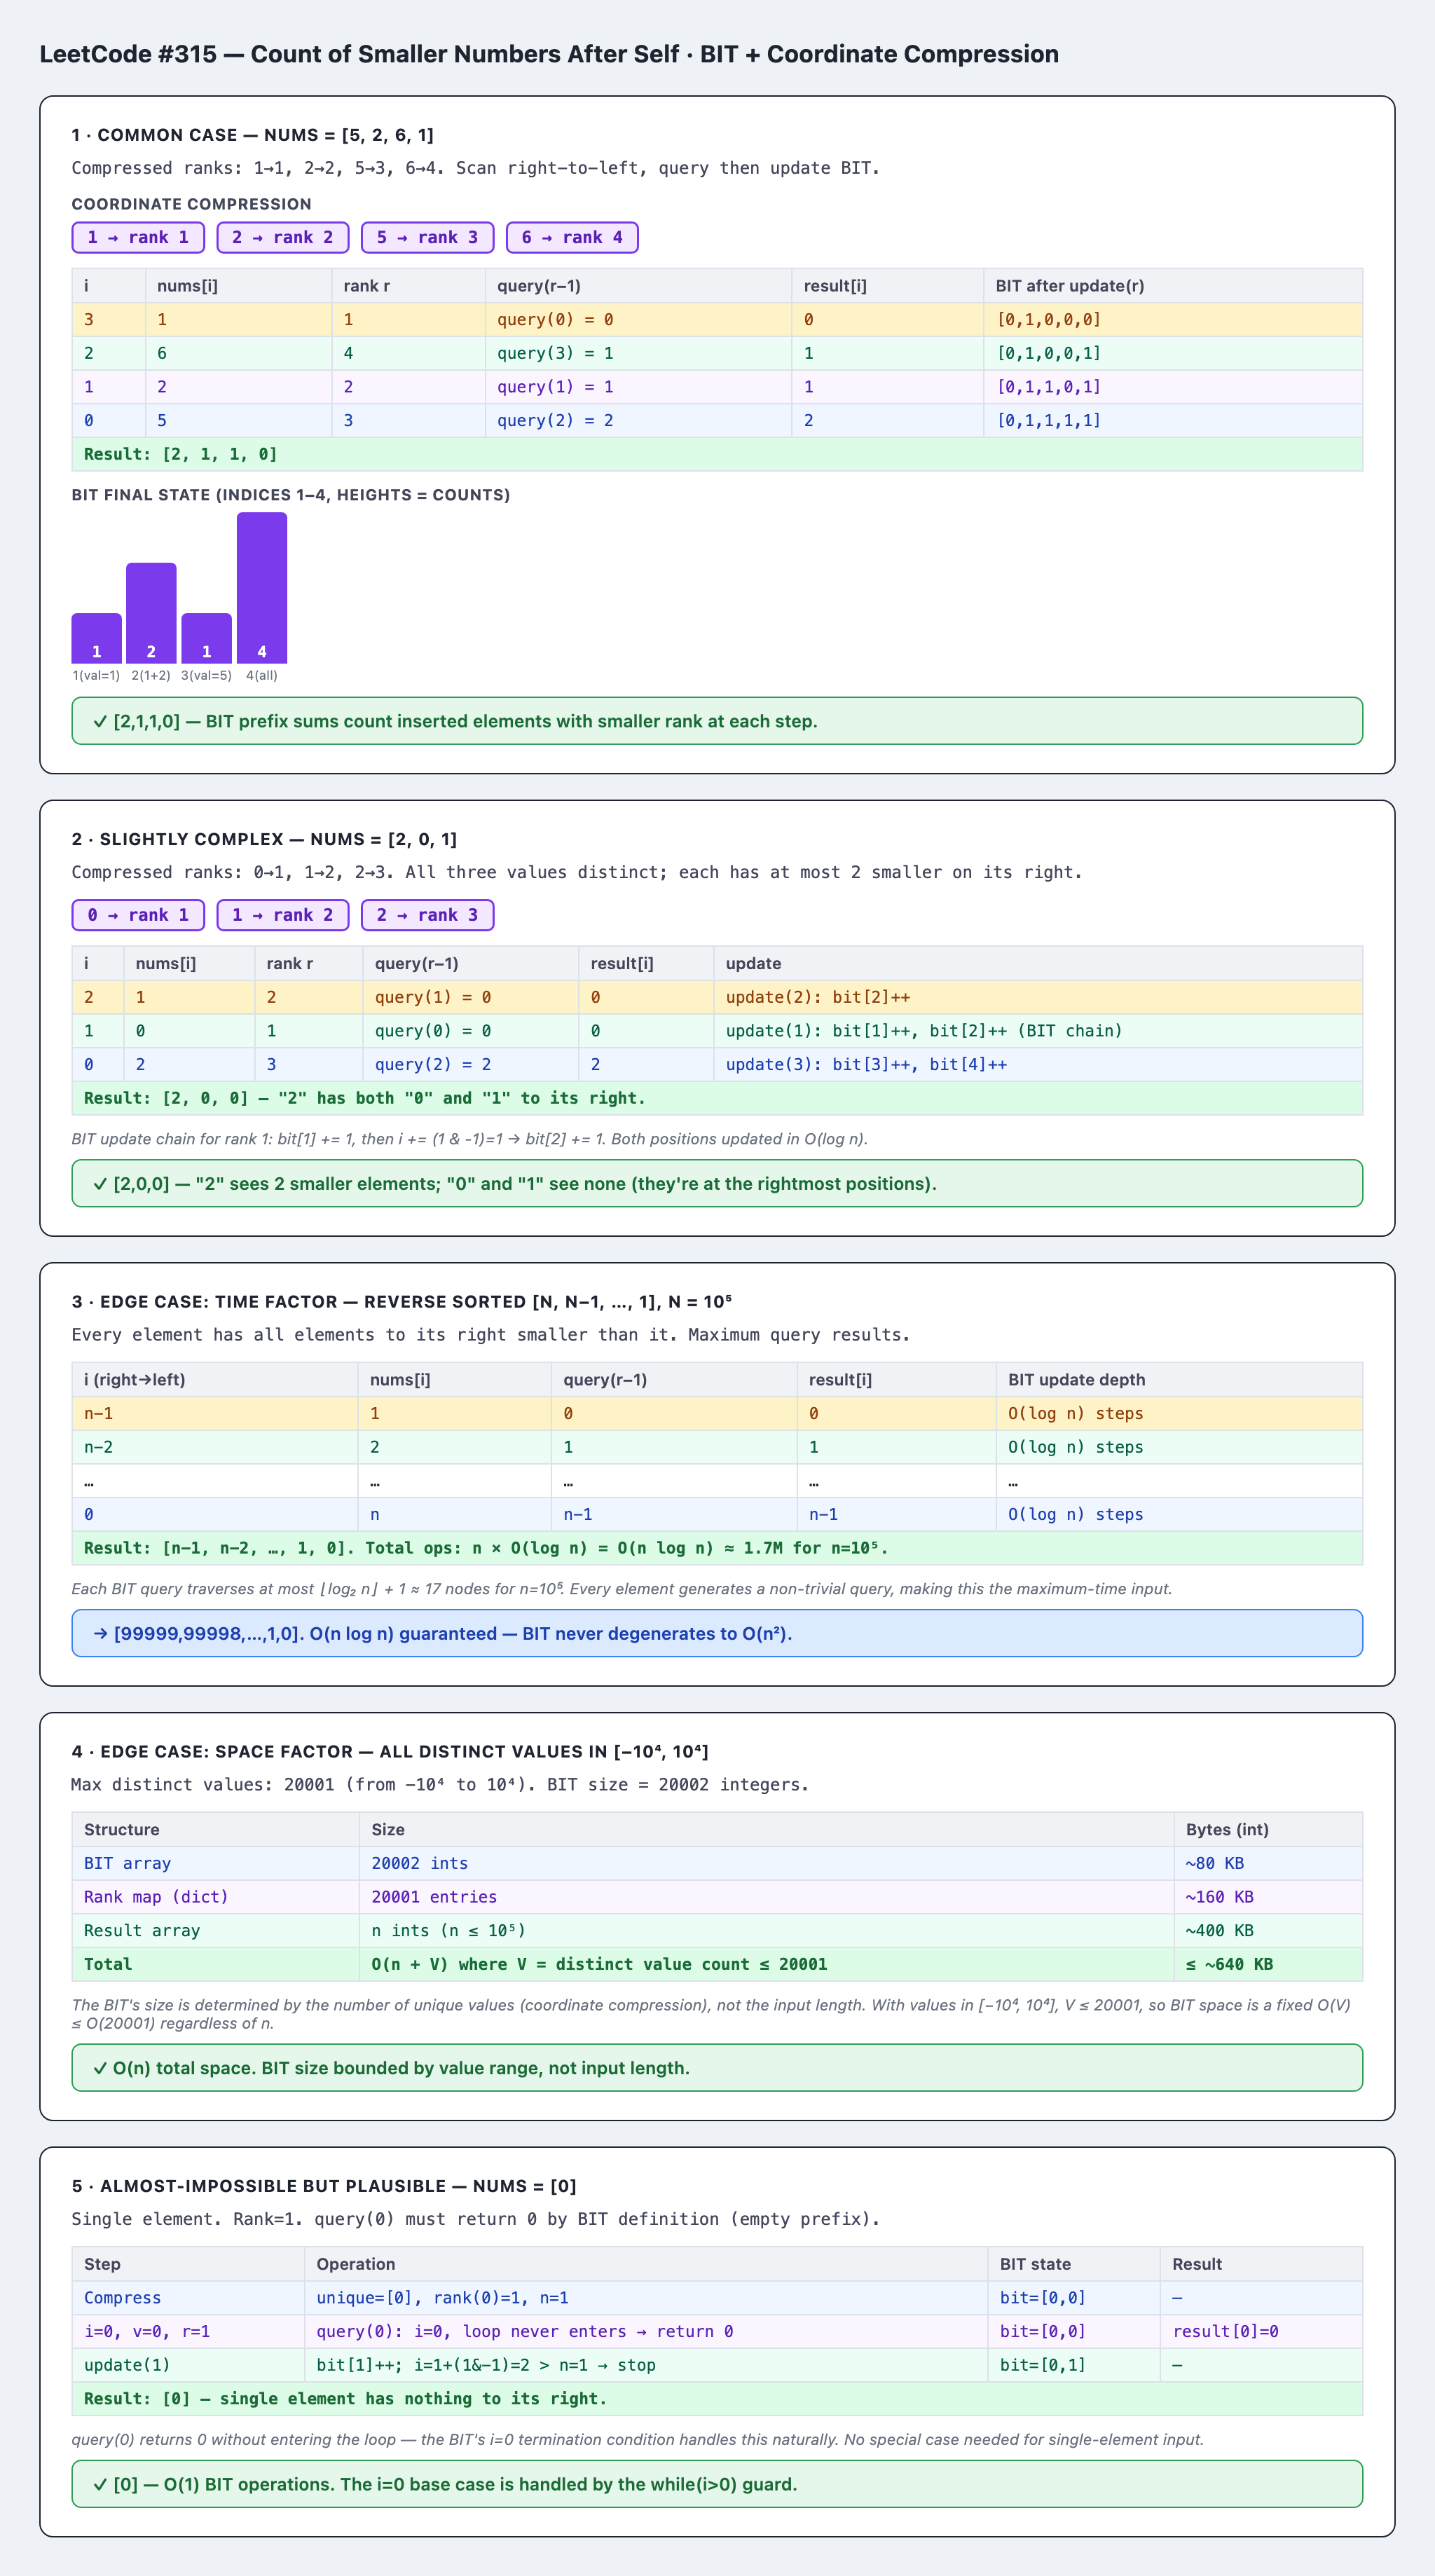